Extracted '/home/hadoop_neel/Project - Prodigal/All_Conversations.zip' into 'All_Conversations/'
Saved metrics to 'call_quality_metrics.csv'
Generated distribution and boxplot visualizations: 'silence_distribution.png', 'overtalk_distribution.png', 'silence_overtalk_boxplot.png'


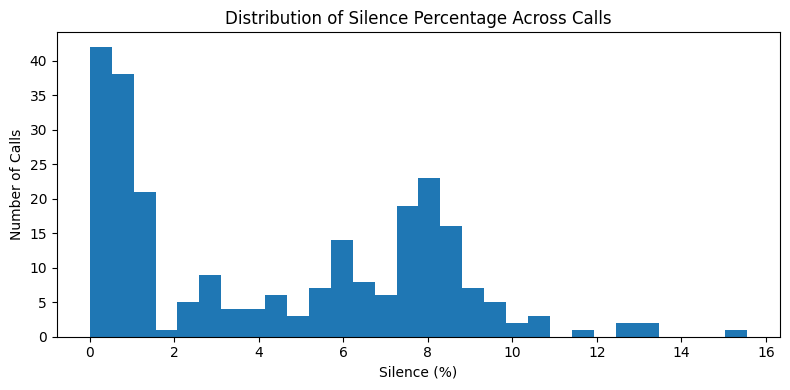

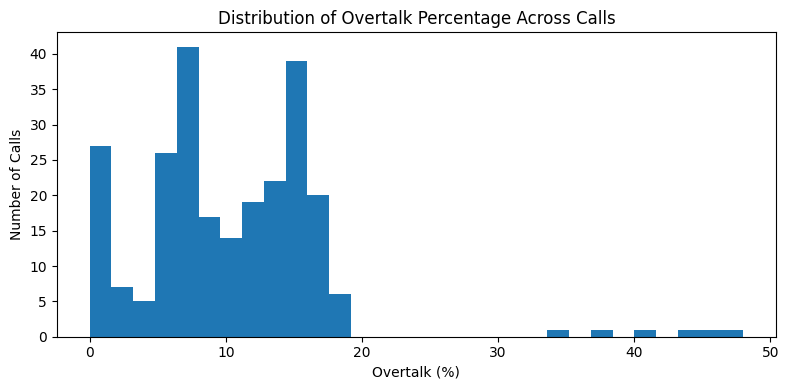

<Figure size 600x400 with 0 Axes>

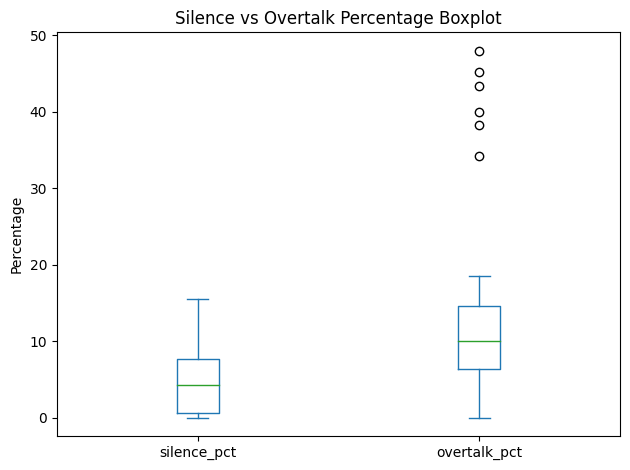

In [3]:
import os
import json
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

# Path to the ZIP file and target extraction directory
ZIP_PATH = '/home/hadoop_neel/Project - Prodigal/All_Conversations.zip'
EXTRACT_DIR = 'All_Conversations'

# Extract if needed
if not os.path.isdir(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print(f"Extracted '{ZIP_PATH}' into '{EXTRACT_DIR}/'")

# List to store metrics
metrics = []

# Process each file
for filename in os.listdir(EXTRACT_DIR):
    filepath = os.path.join(EXTRACT_DIR, filename)
    call_id, ext = os.path.splitext(filename)
    if ext.lower() not in ['.json', '.yaml', '.yml']:
        continue

    # Load conversation
    with open(filepath, 'r') as f:
        try:
            convo = json.load(f) if ext.lower() == '.json' else yaml.safe_load(f)
        except Exception as e:
            continue

    # Validate utterances list
    if not isinstance(convo, list) or len(convo) == 0:
        continue

    # Collect time segments
    segments = [(utt['stime'], utt['etime']) for utt in convo if 'stime' in utt and 'etime' in utt]
    if len(segments) < 2:
        continue
    segments.sort(key=lambda x: x[0])

    # Compute durations
    total_duration = segments[-1][1] - segments[0][0]
    if total_duration <= 0:
        continue

    silence = 0.0
    overtalk = 0.0
    prev_end = segments[0][1]

    for start, end in segments[1:]:
        if start < prev_end:
            overtalk += prev_end - start
        else:
            silence += start - prev_end
        prev_end = max(prev_end, end)

    # Compute percentages
    silence_pct = (silence / total_duration) * 100
    overtalk_pct = (overtalk / total_duration) * 100

    metrics.append({
        'call_id': call_id,
        'total_duration_s': total_duration,
        'silence_pct': silence_pct,
        'overtalk_pct': overtalk_pct
    })

# Create DataFrame and save CSV
df = pd.DataFrame(metrics)
if df.empty:
    print("No valid calls processed.")
    exit()

df.to_csv('call_quality_metrics.csv', index=False)
print("Saved metrics to 'call_quality_metrics.csv'")

# Plot distributions instead of per-call bars for large sample size
# Histogram of Silence Percentage
plt.figure(figsize=(8, 4))
df['silence_pct'].plot(kind='hist', bins=30)
plt.title('Distribution of Silence Percentage Across Calls')
plt.xlabel('Silence (%)')
plt.ylabel('Number of Calls')
plt.tight_layout()
plt.savefig('silence_distribution.png')

# Histogram of Overtalk Percentage
plt.figure(figsize=(8, 4))
df['overtalk_pct'].plot(kind='hist', bins=30)
plt.title('Distribution of Overtalk Percentage Across Calls')
plt.xlabel('Overtalk (%)')
plt.ylabel('Number of Calls')
plt.tight_layout()
plt.savefig('overtalk_distribution.png')

# Boxplots for quick summary
plt.figure(figsize=(6, 4))
df[['silence_pct', 'overtalk_pct']].plot(kind='box')
plt.title('Silence vs Overtalk Percentage Boxplot')
plt.ylabel('Percentage')
plt.tight_layout()
plt.savefig('silence_overtalk_boxplot.png')

print("Generated distribution and boxplot visualizations: 'silence_distribution.png', 'overtalk_distribution.png', 'silence_overtalk_boxplot.png'")
